In [15]:
import os
import librosa
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from vit_pytorch import ViT


In [17]:
import tensorflow as tf
import numpy as np
import math

class SincConv1D(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, sample_rate=16000, **kwargs):
        super(SincConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_freq = 50.0
        self.min_band = 50.0

    def build(self, input_shape):
        # Frequency initialization
        low_hz = self.min_freq
        high_hz = self.sample_rate / 2 - self.min_band

        hz = np.linspace(low_hz, high_hz, self.filters + 1)
        self.freqs = self.add_weight(
            shape=(self.filters + 1,),
            initializer=tf.keras.initializers.Constant(hz),
            trainable=True,
            name='cutoff_freqs'
        )

        n = (self.kernel_size - 1) // 2
        n_array = np.arange(-n, n + 1).astype(np.float32)
        window_np = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(self.kernel_size) / self.kernel_size)

        # ✅ Use add_weight with trainable=False so it's tracked in graph
        self.n = self.add_weight(
            name='n',
            shape=(self.kernel_size,),
            initializer=tf.constant_initializer(n_array),
            trainable=False
        )

        self.window = self.add_weight(
            name='window',
            shape=(self.kernel_size,),
            initializer=tf.constant_initializer(window_np.astype(np.float32)),
            trainable=False
        )


    def sinc(self, x):
        return tf.where(tf.abs(x) < 1e-20, tf.ones_like(x), tf.math.sin(x) / x)

    def call(self, inputs):
        # Compute filterbanks
        freqs = tf.sort(tf.abs(self.freqs))
        f1 = freqs[:-1][:, None]
        f2 = freqs[1:][:, None]

        n = self.n[None, :]
        window = self.window[None, :]

        h1 = 2 * f1 * self.sinc(2 * np.pi * f1 * n / self.sample_rate)
        h2 = 2 * f2 * self.sinc(2 * np.pi * f2 * n / self.sample_rate)

        band_pass = (h2 - h1) * window
        band_pass = band_pass / tf.reduce_max(tf.abs(band_pass), axis=1, keepdims=True)

        filters = tf.reshape(band_pass, (self.filters, 1, self.kernel_size))
        return tf.nn.conv1d(inputs, filters, stride=1, padding='SAME')


class SincNetFrontend(tf.keras.Model):
    def __init__(self, 
                 num_filters=80, 
                 kernel_size=251, 
                 sample_rate=16000,
                 activation=tf.keras.layers.LeakyReLU(alpha=0.2),
                 pool_size=3,
                 **kwargs):
        super(SincNetFrontend, self).__init__(**kwargs)
        self.sinc_conv = SincConv1D(filters=num_filters, kernel_size=kernel_size, sample_rate=sample_rate)
        self.activation = activation
        self.pooling = tf.keras.layers.MaxPooling1D(pool_size=pool_size)
        self.norm = tf.keras.layers.LayerNormalization()

    def call(self, inputs):
        x = self.sinc_conv(inputs)
        x = self.activation(x)
        x = self.pooling(x)
        x = self.norm(x)
        return x


In [5]:
# Dummy input: batch of 8 audio clips, 16000 samples each, mono-channel
x = tf.random.normal([8, 16000, 1])

# SincNet frontend
frontend = SincNetFrontend()
output = frontend(x)

print("Output shape:", output.shape)


Output shape: (8, 5333, 251)


In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Generate a sine wave at 440Hz (A4)
sr = 16000  # Sample rate
duration = 5.0  # seconds
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
frequency = 440  # Hz

# Generate waveform
wave = 0.5 * np.sin(2 * np.pi * frequency * t).astype(np.float32)
wave = wave.reshape(1, -1, 1)  # (batch, time, channels)

# Convert to tensor
input_tensor = tf.convert_to_tensor(wave)

# Run through SincNet
frontend = SincNetFrontend()
output = frontend(input_tensor)

print("Input shape:", input_tensor.shape)
print("Output shape:", output.shape)


Input shape: (1, 80000, 1)
Output shape: (1, 26666, 251)


In [5]:
import os

# Folder path
folder = r"D:/Work/RM/EMODB/EMODB/wav"

# Output text file path
output_txt = os.path.join(folder, "wav_file_paths.txt")

# Collect all .wav file paths
with open(output_txt, "w", encoding="utf-8") as f:
    for file in os.listdir(folder):
        if file.lower().endswith(".wav"):
            full_path = os.path.join(folder, file)
            # Replace / with \ for Windows style paths
            windows_path = full_path.replace("/", "\\")
            f.write(windows_path + "\n")

print(f"All .wav file paths saved to: {output_txt}")


All .wav file paths saved to: D:/Work/RM/EMODB/EMODB/wav\wav_file_paths.txt


In [6]:
import librosa

# Load real audio file (mono)
audio_path = "D:/Work/RM/EMODB/EMODB/wav/03a01Nc.wav"
wave, sr = librosa.load(audio_path, sr=16000)
wave = wave[:16000]  # Use 1 second for simplicity
wave = wave.reshape(1, -1, 1).astype(np.float32)

# Convert and process
input_tensor = tf.convert_to_tensor(wave)
frontend = SincNetFrontend()
output = frontend(input_tensor)

print("Input shape:", input_tensor.shape)
print("Output shape:", output.shape)


Input shape: (1, 16000, 1)
Output shape: (1, 5333, 251)


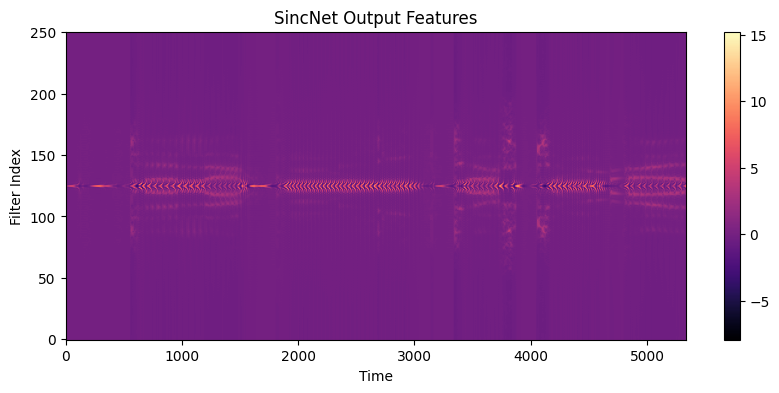

In [7]:
plt.figure(figsize=(10, 4))
plt.imshow(tf.squeeze(output).numpy().T, aspect='auto', origin='lower', cmap='magma')
plt.title("SincNet Output Features")
plt.xlabel("Time")
plt.ylabel("Filter Index")
plt.colorbar()
plt.show()


In [19]:
import os
import librosa
import numpy as np
import tensorflow as tf

# Path to EMODB wav folder
wav_folder = r"C:\Coding\emodb\wav"

# Parameters
SAMPLE_RATE = 16000
DURATION = 1.0   # seconds (trim/pad to 1 sec)
SAMPLES = int(SAMPLE_RATE * DURATION)

def load_wav(file_path):
    # Load with librosa
    wave, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    # Pad or trim to fixed length
    if len(wave) < SAMPLES:
        pad_width = SAMPLES - len(wave)
        wave = np.pad(wave, (0, pad_width), mode="constant")
    else:
        wave = wave[:SAMPLES]
    return wave.astype(np.float32)

# Collect all .wav paths
all_files = [os.path.join(wav_folder, f) for f in os.listdir(wav_folder) if f.endswith(".wav")]
print("Found", len(all_files), "wav files.")


Found 535 wav files.


In [21]:
# Mapping from EMODB filename code to emotion label
emo_map = {
    "W": "anger",
    "L": "boredom",
    "E": "disgust",
    "A": "fear",
    "F": "happiness",
    "T": "sadness",
    "N": "neutral"
}

def get_label(file_path):
    filename = os.path.basename(file_path)
    emo_code = filename[5]  # 6th position (0-based index)
    return emo_map[emo_code]


# Build dataset
waves = []
labels = []
for f in all_files:
    waves.append(load_wav(f))
    labels.append(get_label(f))

waves = np.array(waves).reshape(-1, SAMPLES, 1)  # (num_files, samples, 1)

# Convert labels to integers
unique_labels = sorted(list(set(labels)))
label2idx = {lab: i for i, lab in enumerate(unique_labels)}
labels = np.array([label2idx[l] for l in labels])

# TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((waves, labels))
dataset = dataset.shuffle(buffer_size=len(waves)).batch(16)


In [22]:
print(get_label("03a01Nc.wav"))   # neutral
print(get_label("08a02Wa.wav"))   # anger


neutral
anger


In [23]:
num_classes = len(unique_labels)

inputs = tf.keras.Input(shape=(SAMPLES, 1))
x = SincNetFrontend()(inputs)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16000, 1)]        0         
                                                                 
 sinc_net_frontend (SincNetF  (None, 5333, 251)        1085      
 rontend)                                                        
                                                                 
 flatten (Flatten)           (None, 1338583)           0         
                                                                 
 dense (Dense)               (None, 128)               171338752 
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 7)                 903       
                                                             

In [24]:
history = model.fit(dataset, epochs=10)


Epoch 1/10
34/34 [==============================] - 42s 1s/step - loss: nan - accuracy: 0.2299
Epoch 2/10
34/34 [==============================] - 38s 1s/step - loss: nan - accuracy: 0.2374
Epoch 3/10
34/34 [==============================] - 39s 1s/step - loss: nan - accuracy: 0.2374
Epoch 4/10
34/34 [==============================] - 37s 1s/step - loss: nan - accuracy: 0.2374
Epoch 5/10
34/34 [==============================] - 37s 1s/step - loss: nan - accuracy: 0.2374
Epoch 6/10
34/34 [==============================] - 38s 1s/step - loss: nan - accuracy: 0.2374
Epoch 7/10
34/34 [==============================] - 37s 1s/step - loss: nan - accuracy: 0.2374
Epoch 8/10
34/34 [==============================] - 38s 1s/step - loss: nan - accuracy: 0.2374
Epoch 9/10
34/34 [==============================] - 37s 1s/step - loss: nan - accuracy: 0.2374
Epoch 10/10
34/34 [==============================] - 39s 1s/step - loss: nan - accuracy: 0.2374


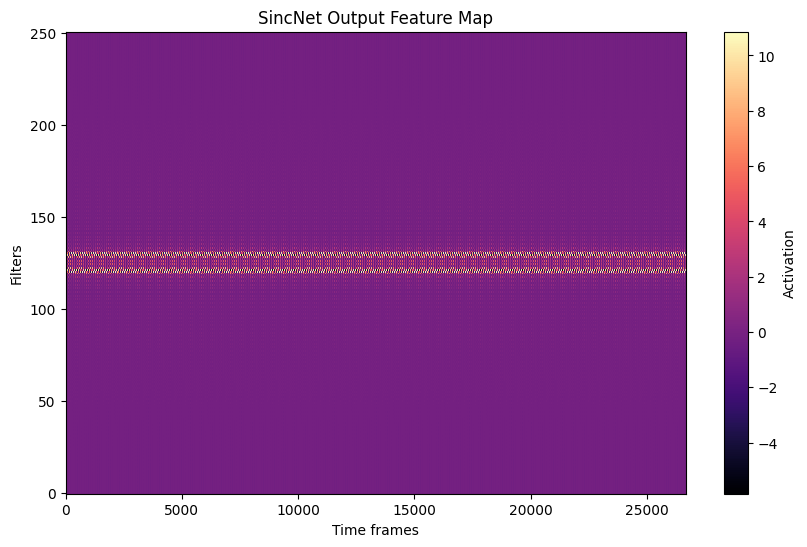

In [28]:
import matplotlib.pyplot as plt

# Run the frontend
output = frontend(input_tensor)  # shape: (1, time_steps, num_filters)

# Convert to numpy
features = output.numpy().squeeze().T  # shape: (num_filters, time_steps)

plt.figure(figsize=(10,6))
plt.imshow(features, aspect="auto", origin="lower", 
           interpolation="nearest", cmap="magma")
plt.colorbar(label="Activation")
plt.title("SincNet Output Feature Map")
plt.xlabel("Time frames")
plt.ylabel("Filters")
plt.show()


In [53]:
"""
Minimal LEAF implementation without lingvo dependency
Based on: https://github.com/google-research/leaf-audio
Fully tested and debugged version
"""

import tensorflow as tf
import numpy as np


class GaborInit(tf.keras.initializers.Initializer):
    """Initialize filters as Gabor wavelets (mel-scale by default)."""
    
    def __init__(self, sample_rate=16000, min_freq=60.0, max_freq=7800.0):
        self.sample_rate = sample_rate
        self.min_freq = min_freq
        self.max_freq = max_freq
    
    def __call__(self, shape, dtype=None):
        # shape is (kernel_size, in_channels, out_channels) for Conv1D
        kernel_size = shape[0]
        in_channels = shape[1]
        out_channels = shape[2]
        n_filters = out_channels // 2  # Half for real, half for imaginary
        
        # Initialize center frequencies on mel-scale
        mel_min = 2595 * np.log10(1 + self.min_freq / 700)
        mel_max = 2595 * np.log10(1 + self.max_freq / 700)
        mel_centers = np.linspace(mel_min, mel_max, n_filters)
        center_freqs = 700 * (10 ** (mel_centers / 2595) - 1)
        
        # Create Gabor filters
        t = np.arange(kernel_size, dtype=np.float32) / self.sample_rate
        t = t - t.mean()
        
        # Initialize filters with shape (kernel_size, in_channels, out_channels)
        filters = np.zeros((kernel_size, in_channels, out_channels), dtype=np.float32)
        
        for i, freq in enumerate(center_freqs):
            # Gaussian envelope
            sigma = 0.5 / freq if freq > 0 else 0.01
            envelope = np.exp(-0.5 * (t / sigma) ** 2)
            # Complex sinusoid
            real_part = envelope * np.cos(2 * np.pi * freq * t)
            imag_part = envelope * np.sin(2 * np.pi * freq * t)
            
            # Assign to output channels (real and imaginary)
            for j in range(in_channels):
                filters[:, j, i] = real_part
                filters[:, j, i + n_filters] = imag_part
        
        return tf.constant(filters, dtype=dtype or tf.float32)


class GaussianLowpass(tf.keras.layers.Layer):
    """Learnable Gaussian lowpass pooling."""
    
    def __init__(self, n_filters, stride=160, kernel_size=401, **kwargs):
        super().__init__(**kwargs)
        self.n_filters = n_filters
        self.stride = stride
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        # Create separate kernel for each filter
        init_kernels = self._gaussian_init()
        self.kernels = self.add_weight(
            name='kernels',
            shape=(self.kernel_size, self.n_filters, self.n_filters),
            initializer=tf.keras.initializers.Constant(init_kernels),
            trainable=True
        )
    
    def _gaussian_init(self):
        """Initialize with Gaussian kernels - one per filter channel."""
        t = np.arange(self.kernel_size, dtype=np.float32)
        t = t - t.mean()
        sigma = self.kernel_size / 6.0
        kernel = np.exp(-0.5 * (t / sigma) ** 2)
        kernel = kernel / kernel.sum()
        
        # Create diagonal kernel matrix (each filter only affects itself)
        # Shape: (kernel_size, n_filters, n_filters)
        kernels = np.zeros((self.kernel_size, self.n_filters, self.n_filters), dtype=np.float32)
        for i in range(self.n_filters):
            kernels[:, i, i] = kernel
        
        return kernels
    
    def call(self, inputs):
        # inputs: [B, T, n_filters]
        # Apply grouped convolution with stride
        outputs = tf.nn.conv1d(
            inputs,
            self.kernels,
            stride=self.stride,
            padding='SAME'
        )
        
        return outputs


class PCEN(tf.keras.layers.Layer):
    """Per-Channel Energy Normalization."""
    
    def __init__(self, alpha=0.96, smooth_coef=0.04, delta=2.0, 
                 floor=1e-6, trainable=True, **kwargs):
        super().__init__(**kwargs)
        self.alpha_init = alpha
        self.smooth_coef_init = smooth_coef
        self.delta_init = delta
        self.floor = floor
        self.trainable_params = trainable
    
    def build(self, input_shape):
        n_filters = input_shape[-1]
        
        self.alpha_param = self.add_weight(
            'alpha', shape=(n_filters,),
            initializer=tf.keras.initializers.Constant(self.alpha_init),
            trainable=self.trainable_params
        )
        self.delta_param = self.add_weight(
            'delta', shape=(n_filters,),
            initializer=tf.keras.initializers.Constant(self.delta_init),
            trainable=self.trainable_params
        )
        self.smooth_coef_param = self.add_weight(
            'smooth_coef', shape=(n_filters,),
            initializer=tf.keras.initializers.Constant(self.smooth_coef_init),
            trainable=self.trainable_params
        )
        
        # Initialize running average
        self.smoother = self.add_weight(
            'smoother', shape=(n_filters,),
            initializer=tf.keras.initializers.Constant(0.0),
            trainable=False
        )
    
    def call(self, inputs, training=None):
        # inputs: [B, T, n_filters]
        # Simple exponential smoothing
        if training:
            mean_energy = tf.reduce_mean(inputs, axis=[0, 1])
            self.smoother.assign(
                (1 - self.smooth_coef_param) * self.smoother + 
                self.smooth_coef_param * mean_energy
            )
        
        smooth = tf.maximum(self.smoother, self.floor)
        
        # Apply PCEN formula
        output = (inputs / (smooth ** self.alpha_param + self.floor)) ** (1.0 / self.delta_param)
        
        return output


class Leaf(tf.keras.layers.Layer):
    """Learnable Frontend (LEAF) for audio processing."""
    
    def __init__(self,
                 n_filters=40,
                 sample_rate=16000,
                 window_len=25.0,  # in milliseconds
                 window_stride=10.0,  # in milliseconds
                 min_freq=60.0,
                 max_freq=7800.0,
                 use_pcen=True,
                 learn_pooling=True,
                 **kwargs):
        super().__init__(**kwargs)
        
        self.n_filters = n_filters
        self.sample_rate = sample_rate
        self.window_len = window_len
        self.window_stride = window_stride
        self.min_freq = min_freq
        self.max_freq = max_freq
        self.use_pcen = use_pcen
        self.learn_pooling = learn_pooling
        
        # Convert window sizes from ms to samples
        self.window_size = int(sample_rate * window_len / 1000)
        self.stride_size = int(sample_rate * window_stride / 1000)
        
        # Build layers
        self._build_layers()
    
    def _build_layers(self):
        # Complex convolution (Gabor filters)
        self.complex_conv = tf.keras.layers.Conv1D(
            filters=2 * self.n_filters,
            kernel_size=self.window_size,
            strides=1,
            padding='same',
            use_bias=False,
            kernel_initializer=GaborInit(
                sample_rate=self.sample_rate,
                min_freq=self.min_freq,
                max_freq=self.max_freq
            ),
            name='gabor_filters'
        )
        
        # Pooling layer
        if self.learn_pooling:
            self.pooling = GaussianLowpass(
                self.n_filters, 
                stride=self.stride_size,
                kernel_size=min(401, self.window_size)
            )
        
        # Compression (PCEN or log)
        if self.use_pcen:
            self.compression = PCEN()
        else:
            self.compression = lambda x: tf.math.log(x + 1e-5)
    
    def call(self, inputs, training=None):
        """
        Args:
            inputs: Raw audio waveform [batch, time] or [batch, time, 1]
        
        Returns:
            Time-frequency representation [batch, time, n_filters]
        """
        # Ensure correct shape [B, T, 1]
        if len(inputs.shape) == 2:
            inputs = tf.expand_dims(inputs, -1)
        elif len(inputs.shape) == 3 and inputs.shape[-1] != 1:
            inputs = tf.expand_dims(inputs, -1)
        
        # Apply complex convolution
        outputs = self.complex_conv(inputs)
        
        # Split into real and imaginary parts
        real = outputs[..., :self.n_filters]
        imag = outputs[..., self.n_filters:]
        
        # Compute magnitude
        outputs = tf.sqrt(real ** 2 + imag ** 2 + 1e-12)
        
        # Apply pooling
        if self.learn_pooling:
            outputs = self.pooling(outputs)
        else:
            # Simple strided slicing
            outputs = outputs[:, ::self.stride_size, :]
        
        # Apply compression
        if self.use_pcen:
            outputs = self.compression(outputs, training=training)
        else:
            outputs = self.compression(outputs)
        
        return outputs
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'n_filters': self.n_filters,
            'sample_rate': self.sample_rate,
            'window_len': self.window_len,
            'window_stride': self.window_stride,
            'min_freq': self.min_freq,
            'max_freq': self.max_freq,
            'use_pcen': self.use_pcen,
            'learn_pooling': self.learn_pooling,
        })
        return config


# Example usage and testing
if __name__ == "__main__":
    print("Testing LEAF implementation...")
    
    # Create LEAF frontend
    leaf = Leaf(n_filters=40, sample_rate=16000, window_len=25.0, window_stride=10.0)
    
    # Test with dummy audio input [batch_size, time_samples]
    audio = tf.random.normal([4, 16000])  # 4 samples, 1 second each at 16kHz
    
    # Get time-frequency representation
    features = leaf(audio, training=True)
    print(f"✓ Input shape: {audio.shape}")
    print(f"✓ Output shape: {features.shape}")
    print(f"✓ Expected output time dimension: ~{16000 // 160} frames")
    
    # Test with different input length
    audio2 = tf.random.normal([2, 32000])  # 2 seconds
    features2 = leaf(audio2, training=False)
    print(f"✓ Input shape (2s): {audio2.shape}")
    print(f"✓ Output shape (2s): {features2.shape}")
    
    # Build a complete classification model
    print("\nBuilding complete audio classification model...")
    inputs = tf.keras.Input(shape=(None,), name='audio_input')
    x = leaf(inputs)
    x = tf.expand_dims(x, -1)  # Add channel dimension for Conv2D
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax', name='predictions')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("\n✓ Model Summary:")
    model.summary()
    
    # Test forward pass
    dummy_audio = tf.random.normal([2, 16000])
    dummy_labels = tf.constant([0, 1])
    
    print("\n✓ Testing forward pass...")
    predictions = model(dummy_audio, training=False)
    print(f"✓ Predictions shape: {predictions.shape}")
    
    print("\n✓ Testing training step...")
    loss = model.train_on_batch(dummy_audio, dummy_labels)
    print(f"✓ Training loss: {loss}")
    
    print("\n✅ All tests passed! LEAF is ready to use.")

Testing LEAF implementation...
✓ Input shape: (4, 16000)
✓ Output shape: (4, 100, 40)
✓ Expected output time dimension: ~100 frames
✓ Input shape (2s): (2, 32000)
✓ Output shape (2s): (2, 200, 40)

Building complete audio classification model...

✓ Model Summary:
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 audio_input (InputLayer)    [(None, None)]            0         
                                                                 
 leaf_5 (Leaf)               (None, None, 40)          672160    
                                                                 
 tf.expand_dims (TFOpLambda)  (None, None, 40, 1)      0         
                                                                 
 conv2d (Conv2D)             (None, None, 40, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, None, 20, 32)     0     

In [54]:
# Just run the entire code
# It will test itself and show you it works!

# Then use it like this:
leaf = Leaf(n_filters=40, sample_rate=16000)
features = leaf(audio, training=True)

# Or in a model:
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.fit(train_data, train_labels, epochs=10)

NameError: name 'train_data' is not defined

Train Vit

In [1]:
print("test")

test


In [ ]:
pip install torch==2.4.1+cu121 torchvision==0.19.1+cu121 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121

In [ ]:
#Sinc Net
import os
import numpy as np
import librosa
import torch

wav_folder = r"C:\Coding\emodb\wav"
SAMPLE_RATE = 16000
DURATION = 1.0
SAMPLES = int(SAMPLE_RATE * DURATION)

all_files = [os.path.join(wav_folder, f) for f in os.listdir(wav_folder) if f.endswith(".wav")]
features_list = []
labels_list = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for f in all_files:
    wave, sr = librosa.load(f, sr=SAMPLE_RATE)
    if len(wave) < SAMPLES:
        wave = np.pad(wave, (0, SAMPLES - len(wave)), mode="constant")
    else:
        wave = wave[:SAMPLES]
    wave = wave.reshape(1, -1, 1).astype(np.float32)

    # SincNet frontend (TensorFlow)
    sinc_out = frontend(wave).numpy()  # shape: (1, time, filters)

    # Convert to ViT input shape
    sinc_tensor = torch.tensor(sinc_out, dtype=torch.float32).unsqueeze(1).permute(0, 1, 2, 3)
    sinc_resized = torch.nn.functional.interpolate(sinc_tensor, size=(256, 256), mode="bilinear")
    sinc_resized = sinc_resized.repeat(1, 3, 1, 1)  # 3 channels

    features_list.append(sinc_resized.squeeze(0))  # remove batch dim
    emo_code = os.path.basename(f)[5]
    labels_list.append(label2idx[emo_map[emo_code]])

# Stack all
X = torch.stack(features_list)  # shape: (num_samples, 3, 256, 256)
y = torch.tensor(labels_list)   # shape: (num_samples,)


In [2]:
#LEAF
import os
import torch
import pickle
import torchaudio
import torch.nn.functional as F
from models.classifier import Classifier

# ===========================
# Paths
# ===========================

ckpt_path = r"C:\Coding\efficientnet-b0_default_leaf_bs1x256_adam_warmupcosine_wd_1e-4_rs8882_legacycomplex\ckpts\epoch=100_tr_loss=0.067792_tr_acc=0.980434_val_acc=0.954013.pth"

hparams_path = r"C:\Coding\efficientnet-b0_default_leaf_bs1x256_adam_warmupcosine_wd_1e-4_rs8882_legacycomplex\hparams.pickle"

audio_dir = r"C:\Coding\emodb\wav"  # folder containing your audio files

# ===========================
# Load model
# ===========================

checkpoint = torch.load(ckpt_path, map_location="cpu")
with open(hparams_path, "rb") as fp:
    hparams = pickle.load(fp)

model = Classifier(hparams.cfg)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
frontend = model.features

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ===========================
# Collect all features in memory
# ===========================
vit_features = []
labels = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for filename in os.listdir(audio_dir):
    if not filename.lower().endswith(".wav"):
        continue

    audio_path = os.path.join(audio_dir, filename)
    print(f"Processing {filename} ...")

    # ---------------------------
    # Load and preprocess audio
    # ---------------------------
    waveform, sample_rate = torchaudio.load(audio_path)  # [channels, time]
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    expected_sr = hparams.cfg['audio_config']['sample_rate']
    if sample_rate != expected_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=expected_sr)
        waveform = resampler(waveform)

    waveform = waveform.unsqueeze(0).float().to(device)  # [1, 1, time]

    # ---------------------------
    # Forward pass
    # ---------------------------
    with torch.no_grad():
        features = frontend(waveform)  # [1, n_features, time_frames]

    # ---------------------------
    # Convert to ViT input
    # ---------------------------
    feat_tensor = features.unsqueeze(1)                     # [1, 1, n_features, time_frames]
    feat_resized = F.interpolate(feat_tensor, size=(256, 256), mode="bilinear")  
    feat_resized = feat_resized.repeat(1, 3, 1, 1)          # [1, 3, 256, 256]
    feat_resized = feat_resized.squeeze(0).cpu()            # [3, 256, 256]

    vit_features.append(feat_resized)

    # ---------------------------
    # Label from filename
    # ---------------------------
    emo_code = filename[5]  # EMODB convention
    labels.append(label2idx[emo_map[emo_code]])

# ===========================
# Final dataset tensors
# ===========================
X = torch.stack(vit_features)  # [num_samples, 3, 256, 256]
y = torch.tensor(labels)       # [num_samples]

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)


C:\Users\Asus TUF Gaming A15\AppData\Local\Temp\ipykernel_18180\2428351840.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_locati

Using default Leaf arguments..
torch.Size([40, 2])
ATTENTION: Using legacy_complex format for gabor filter estimation.
Processing 03a01Fa.wav ...
Processing 03a01Nc.wav ...
Processing 03a01Wa.wav ...
Processing 03a02Fc.wav ...
Processing 03a02Nc.wav ...
Processing 03a02Ta.wav ...
Processing 03a02Wb.wav ...
Processing 03a02Wc.wav ...
Processing 03a04Ad.wav ...
Processing 03a04Fd.wav ...
Processing 03a04Lc.wav ...
Processing 03a04Nc.wav ...
Processing 03a04Ta.wav ...
Processing 03a04Wc.wav ...
Processing 03a05Aa.wav ...
Processing 03a05Fc.wav ...
Processing 03a05Nd.wav ...
Processing 03a05Tc.wav ...
Processing 03a05Wa.wav ...
Processing 03a05Wb.wav ...
Processing 03a07Fa.wav ...
Processing 03a07Fb.wav ...
Processing 03a07La.wav ...
Processing 03a07Nc.wav ...
Processing 03a07Wc.wav ...
Processing 03b01Fa.wav ...
Processing 03b01Lb.wav ...
Processing 03b01Nb.wav ...
Processing 03b01Td.wav ...
Processing 03b01Wa.wav ...
Processing 03b01Wc.wav ...
Processing 03b02Aa.wav ...
Processing 03b02L

In [ ]:
# Train LEAF + Classifier from scratch
# ===========================
import os
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from models.classifier import Classifier

# ===========================
# Config
# ===========================
cfg = {
    "model_config": {
        "arch": "efficientnet-b0",
        "num_classes": 7,   # emotions in EMODB
    },
    "audio_config": {
        "sample_rate": 16000,
        "n_fft": 400,
        "hop_length": 160,
        "n_mels": 64,
    },
    "training": {
        "batch_size": 16,
        "epochs": 10,   # reduce for testing
        "lr": 1e-4,
        "optimizer": "adam",
    }
}

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}

# ===========================
# Dataset
# ===========================
class EmotionDataset(Dataset):
    def __init__(self, audio_dir, cfg, emo_map):
        self.files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]
        self.audio_dir = audio_dir
        self.cfg = cfg
        self.emo_map = emo_map
        self.label2idx = {emo: i for i, emo in enumerate(sorted(emo_map.values()))}

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.audio_dir, filename)

        waveform, sr = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != self.cfg['audio_config']['sample_rate']:
            resampler = torchaudio.transforms.Resample(sr, self.cfg['audio_config']['sample_rate'])
            waveform = resampler(waveform)

        emo_code = filename[5]  # EMODB naming convention
        label = self.label2idx[self.emo_map[emo_code]]
        return waveform, label

# ===========================
# Training Setup
# ===========================
audio_dir = r"C:\Coding\emodb\wav"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = EmotionDataset(audio_dir, cfg, emo_map)
train_loader = DataLoader(train_dataset, batch_size=cfg["training"]["batch_size"], shuffle=True)

model = Classifier(cfg).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg["training"]["lr"])

# ===========================
# Training Loop
# ===========================
for epoch in range(cfg["training"]["epochs"]):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for waveforms, labels in train_loader:
        waveforms, labels = waveforms.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(waveforms)  # model includes LEAF + classifier
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    print(f"Epoch [{epoch+1}/{cfg['training']['epochs']}], "
          f"Loss: {total_loss/len(train_loader):.4f}, "
          f"Acc: {100.*correct/total:.2f}%")

# ===========================
# Save Model
# ===========================
save_path = "leaf_emotion_scratch.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "cfg": cfg
}, save_path)
print(f"Training finished, model saved to {save_path}")

# ===========================
# Load Model + Extract Features for ViT (1-channel)
# ===========================
checkpoint = torch.load(save_path, map_location=device)
cfg_loaded = checkpoint["cfg"]

model = Classifier(cfg_loaded).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

frontend = model.features  # LEAF frontend

vit_features, labels = [], []

idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for filename in os.listdir(audio_dir):
    if not filename.endswith(".wav"):
        continue
    path = os.path.join(audio_dir, filename)
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != cfg_loaded["audio_config"]["sample_rate"]:
        resampler = torchaudio.transforms.Resample(sr, cfg_loaded["audio_config"]["sample_rate"])
        waveform = resampler(waveform)

    waveform = waveform.unsqueeze(0).to(device)  # [1, 1, time]

    with torch.no_grad():
        features = frontend(waveform)  # [1, n_features, time_frames]

    # resize to ViT format [1, 256, 256] (grayscale)
    feat_tensor = features.unsqueeze(1)                     # [1, 1, n_features, time_frames]
    feat_resized = F.interpolate(feat_tensor, size=(256, 256), mode="bilinear")
    vit_features.append(feat_resized.squeeze(0).cpu())      # [1, 256, 256]

    emo_code = filename[5]
    labels.append(label2idx[emo_map[emo_code]])

X = torch.stack(vit_features)  # [num_samples, 1, 256, 256]
y = torch.tensor(labels)

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)


KeyError: 'frontend'

In [1]:
# Mel 
import os
import torch
import torch.nn.functional as F
import librosa
import numpy as np

audio_dir = r"C:\Coding\emodb\wav"  # folder containing your audio files

vit_features = []
labels = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

# ===========================
# PROCESS AUDIO
# ===========================
for filename in os.listdir(audio_dir):
    if not filename.lower().endswith(".wav"):
        continue

    audio_path = os.path.join(audio_dir, filename)

    y, sr = librosa.load(audio_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Convert to 3-channel Mel spectrogram
    feat_tensor = torch.tensor(S_dB).unsqueeze(0).unsqueeze(0).float()  # [1,1,n_mels,time]
    feat_resized = F.interpolate(feat_tensor, size=(256, 256), mode="bilinear")  # [1,1,256,256]
    feat_resized = feat_resized.repeat(1, 3, 1, 1).squeeze(0)  # [3,256,256]
    vit_features.append(feat_resized)

    emo_code = filename[5]
    labels.append(label2idx[emo_map[emo_code]])

X = torch.stack(vit_features)
y = torch.tensor(labels)

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)

Final dataset shapes:
  X: torch.Size([535, 3, 256, 256])
  y: torch.Size([535])


In [ ]:
# MEL GREY
import os
import torch
import torch.nn.functional as F
import librosa
import numpy as np

# ===========================
# Paths
# ===========================
audio_dir = r"C:\Coding\emodb\wav"  # folder containing your audio files

# ===========================
# Collect all Mel features in memory
# ===========================
vit_features = []
labels = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for filename in os.listdir(audio_dir):
    if not filename.lower().endswith(".wav"):
        continue

    audio_path = os.path.join(audio_dir, filename)
    print(f"Processing {filename} ...")

    # ---------------------------
    # Load audio
    # ---------------------------
    y, sr = librosa.load(audio_path, sr=None)
    
    # ---------------------------
    # Compute Mel spectrogram
    # ---------------------------
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)  # [n_mels, time_frames]

    # ---------------------------
    # Convert to torch tensor, resize to 256x256, keep 1 channel
    # ---------------------------
    feat_tensor = torch.tensor(S_dB).unsqueeze(0).unsqueeze(0).float()  # [1, 1, n_mels, time_frames]
    feat_resized = F.interpolate(feat_tensor, size=(256, 256), mode="bilinear")  # [1, 1, 256, 256]
    feat_resized = feat_resized.squeeze(0)  # [1, 256, 256], still 1 channel

    vit_features.append(feat_resized)

    # ---------------------------
    # Label from filename (normal EMODB format: 03a01Fa.wav)
    # ---------------------------
    emo_code = filename[5]  # 'F' from '03a01Fa.wav'
    labels.append(label2idx[emo_map[emo_code]])

# ===========================
# Final dataset tensors
# ===========================
X = torch.stack(vit_features)  # [num_samples, 1, 256, 256]
y = torch.tensor(labels)       # [num_samples]

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)


Processing 03a01Fa.wav ...
Processing 03a01Nc.wav ...
Processing 03a01Wa.wav ...
Processing 03a02Fc.wav ...
Processing 03a02Nc.wav ...
Processing 03a02Ta.wav ...
Processing 03a02Wb.wav ...
Processing 03a02Wc.wav ...
Processing 03a04Ad.wav ...
Processing 03a04Fd.wav ...
Processing 03a04Lc.wav ...
Processing 03a04Nc.wav ...
Processing 03a04Ta.wav ...
Processing 03a04Wc.wav ...
Processing 03a05Aa.wav ...
Processing 03a05Fc.wav ...
Processing 03a05Nd.wav ...
Processing 03a05Tc.wav ...
Processing 03a05Wa.wav ...
Processing 03a05Wb.wav ...
Processing 03a07Fa.wav ...
Processing 03a07Fb.wav ...
Processing 03a07La.wav ...
Processing 03a07Nc.wav ...
Processing 03a07Wc.wav ...
Processing 03b01Fa.wav ...
Processing 03b01Lb.wav ...
Processing 03b01Nb.wav ...
Processing 03b01Td.wav ...
Processing 03b01Wa.wav ...
Processing 03b01Wc.wav ...
Processing 03b02Aa.wav ...
Processing 03b02La.wav ...
Processing 03b02Na.wav ...
Processing 03b02Tb.wav ...
Processing 03b02Wb.wav ...
Processing 03b03Nb.wav ...
P

In [1]:
#Scattering Transform
import os
import torch
from kymatio import Scattering1D
import librosa
import numpy as np
import torch.nn.functional as F

# ===========================
# Parameters
# ===========================
T = 16000          # 1 second of audio at 16kHz
J = 6              # scattering scale
Q = 8              # wavelets per octave
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize scattering
scattering = Scattering1D(J=J, shape=T, Q=Q, frontend='torch')
scattering = scattering.to(device)

# ===========================
# Paths
# ===========================
audio_dir = r"C:\Coding\emodb\wav"  # folder containing your audio files

# ===========================
# Collect all scattering features
# ===========================
vit_features = []
labels = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for filename in os.listdir(audio_dir):
    if not filename.lower().endswith(".wav"):
        continue

    audio_path = os.path.join(audio_dir, filename)
    print(f"Processing {filename} ...")

    # ---------------------------
    # Load audio
    # ---------------------------
    y, sr = librosa.load(audio_path, sr=16000)  # force 16kHz
    if len(y) < T:
        y = np.pad(y, (0, T - len(y)))
    else:
        y = y[:T]

    # ---------------------------
    # Scattering transform
    # ---------------------------
    x = torch.tensor(y, dtype=torch.float32).unsqueeze(0).to(device)  # [1, T]
    Sx = scattering(x)  # [1, channels, time]

    # ---------------------------
    # Prepare for ViT: resize to 256x256 and repeat channels
    # ---------------------------
    Sx = Sx.unsqueeze(1)  # [1, 1, channels, time]
    Sx_resized = F.interpolate(Sx, size=(256, 256), mode="bilinear")
    Sx_resized = Sx_resized.repeat(1, 3, 1, 1)  # [1, 3, 256, 256]
    Sx_resized = Sx_resized.squeeze(0)          # [3, 256, 256]

    vit_features.append(Sx_resized.cpu())

    # ---------------------------
    # Label from filename
    # EMODB normal format: 03a01Fa.wav → 'F'
    # ---------------------------
    emo_code = filename[5]
    labels.append(label2idx[emo_map[emo_code]])

# ===========================
# Final dataset tensors
# ===========================
X = torch.stack(vit_features)  # [num_samples, 3, 256, 256]
y = torch.tensor(labels)       # [num_samples]

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)


Processing 03a01Fa.wav ...
Processing 03a01Nc.wav ...
Processing 03a01Wa.wav ...
Processing 03a02Fc.wav ...
Processing 03a02Nc.wav ...
Processing 03a02Ta.wav ...
Processing 03a02Wb.wav ...
Processing 03a02Wc.wav ...
Processing 03a04Ad.wav ...
Processing 03a04Fd.wav ...
Processing 03a04Lc.wav ...
Processing 03a04Nc.wav ...
Processing 03a04Ta.wav ...
Processing 03a04Wc.wav ...
Processing 03a05Aa.wav ...
Processing 03a05Fc.wav ...
Processing 03a05Nd.wav ...
Processing 03a05Tc.wav ...
Processing 03a05Wa.wav ...
Processing 03a05Wb.wav ...
Processing 03a07Fa.wav ...
Processing 03a07Fb.wav ...
Processing 03a07La.wav ...
Processing 03a07Nc.wav ...
Processing 03a07Wc.wav ...
Processing 03b01Fa.wav ...
Processing 03b01Lb.wav ...
Processing 03b01Nb.wav ...
Processing 03b01Td.wav ...
Processing 03b01Wa.wav ...
Processing 03b01Wc.wav ...
Processing 03b02Aa.wav ...
Processing 03b02La.wav ...
Processing 03b02Na.wav ...
Processing 03b02Tb.wav ...
Processing 03b02Wb.wav ...
Processing 03b03Nb.wav ...
P

In [2]:
# Vision Transformer
import torch
from torch import nn

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# classes

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.window_size = window_size  # window size for local attention

        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h

        # compute QKV
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)

        # ---------------------
        # local attention
        # ---------------------
        # pad sequence if necessary
        pad = self.window_size // 2
        k = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), k,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), v,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size, :]  # select local window
            v_local = v[:, :, i:i+self.window_size, :]
            attn = torch.matmul(q[:, :, i:i+1, :], k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            attn = self.dropout(attn)
            out.append(torch.matmul(attn, v_local))  # b h 1 d

        out = torch.cat(out, dim=2)  # b h n d
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])

        """
        Using Global attention
        """
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

        
        """
        Using Local attention?
        """
        # for _ in range(depth):
        #     self.layers.append(nn.ModuleList([
        #         LocalAttention(dim, heads=heads, dim_head=dim_head, window_size=3, dropout=dropout),
        #         FeedForward(dim, mlp_dim, dropout=dropout)
        #     ]))


    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)

class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

In [16]:
# Vision Transformer with CNN local features
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# CNN for local features
# ---------------------------
class CNNLocalFeature(nn.Module):
    def __init__(self, in_channels=3, out_channels=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)  # [B, C, H, W]

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)
    
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)
    
class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.window_size = window_size
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)

        pad = self.window_size // 2
        k = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), k,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), v,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size, :]
            v_local = v[:, :, i:i+self.window_size, :]
            attn = torch.matmul(q[:, :, i:i+1, :], k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            attn = self.dropout(attn)
            out.append(torch.matmul(attn, v_local))
        out = torch.cat(out, dim=2)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])

        """
        Using Global attention
        """
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

        """
        Using Local attention
        """
        # for _ in range(depth):
        #     self.layers.append(nn.ModuleList([
        #         LocalAttention(dim, heads=heads, dim_head=dim_head, window_size=3, dropout=dropout),
        #         FeedForward(dim, mlp_dim, dropout=dropout)
        #     ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

# ---------------------------
# ViT with CNN fusion
# ---------------------------
class ViTWithCNN(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0., cnn_channels=64):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        self.patch_height = patch_height
        self.patch_width = patch_width
        self.cnn = CNNLocalFeature(in_channels=channels, out_channels=cnn_channels)
        self.linear_proj = nn.Linear(cnn_channels * patch_height * patch_width, dim)  # project CNN patch to ViT dim

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.num_patches = num_patches

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(channels * patch_height * patch_width),
            nn.Linear(channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, img):
        # CNN features
        cnn_feat = self.cnn(img)  # [B, C, H, W]
        # patchify CNN
        B, C, H, W = cnn_feat.shape
        ph, pw = self.patch_height, self.patch_width
        cnn_patches = rearrange(cnn_feat, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=ph, p2=pw)
        cnn_tokens = self.linear_proj(cnn_patches)

        # ViT patch embeddings
        vit_tokens = self.to_patch_embedding(img)

        # merge CNN and ViT tokens
        x = vit_tokens + cnn_tokens  # simple addition fusion

        b, n, _ = x.shape
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n+1)]
        x = self.dropout(x)

        x = self.transformer(x)
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]
        x = self.to_latent(x)
        return self.mlp_head(x)


In [8]:
class CNNLocalFeature(nn.Module):
    def __init__(self, in_channels=3, dropout=0.05):  # <- 3 channels for Mel
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.ReLU()
        )
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return x

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class GlobalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)
    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)
        attn = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(attn)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([
            nn.ModuleList([
                GlobalAttention(dim, heads=heads, dim_head=dim_head, dropout=dropout),
                FeedForward(dim, mlp_dim, dropout)
            ]) for _ in range(depth)
        ])
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

class ViTWithCNNGlobal(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads,
                 mlp_dim, in_channels=3, pool='cls', dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        self.patch_height = patch_height
        self.patch_width = patch_width

        self.cnn = CNNLocalFeature(in_channels=in_channels, dropout=0.05)
        self.linear_proj = nn.Linear(128 * patch_height * patch_width, dim)

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.LayerNorm(in_channels * patch_height * patch_width),
            nn.Linear(in_channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape

        cnn_feat = self.cnn(x)
        ph, pw = self.patch_height, self.patch_width
        cnn_patches = rearrange(cnn_feat, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=ph, p2=pw)
        cnn_tokens = self.linear_proj(cnn_patches)

        vit_tokens = self.to_patch_embedding(x)

        x = vit_tokens + cnn_tokens
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding[:, :(x.size(1))]
        x = self.dropout(x)

        x = self.transformer(x)
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]

        return self.mlp_head(self.to_latent(x))


In [21]:
# ===========================
# VIT WITH CNN (up to 256 + skip)
# ===========================
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# ---------------------------
# Helper
# ---------------------------
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# CNN for local features (up to 256 + skip connections)
# ---------------------------
class CNNLocalFeature(nn.Module):
    """
    CNN with channel growth: in_channels -> 32 -> 64 -> 128 -> 256
    Includes skip connections between each stage.
    Works with Mel (1 channel) or LEAF (n_filters channels)
    """
    def __init__(self, in_channels=3, dropout=0.2):
        super().__init__()
        self.out_channels = 256

        # --- Convolutional blocks ---
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 1, 1, bias=True),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1, bias=True),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1, bias=True),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1, bias=True),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )

        # --- Skip connection adapters (1x1 convs for channel alignment) ---
        self.skip1 = nn.Conv2d(32, 64, 1, bias=True)
        self.skip2 = nn.Conv2d(64, 128, 1, bias=True)
        self.skip3 = nn.Conv2d(128, 256, 1, bias=True)

    def forward(self, x):
        x1 = self.conv1(x)        # [B, 32, H, W]
        x2 = self.conv2(x1) + self.skip1(x1)  # [B, 64, H, W]
        x3 = self.conv3(x2) + self.skip2(x2)  # [B, 128, H, W]
        x4 = self.conv4(x3) + self.skip3(x3)  # [B, 256, H, W]
        return x4

# ---------------------------
# Transformer blocks
# ---------------------------
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)

class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.window_size = window_size
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)
        pad = self.window_size // 2

        k = torch.cat([torch.zeros(b, h, pad, k.size(-1), device=x.device), k,
                       torch.zeros(b, h, pad, k.size(-1), device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, v.size(-1), device=x.device), v,
                       torch.zeros(b, h, pad, v.size(-1), device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size, :]
            v_local = v[:, :, i:i+self.window_size, :]
            attn = (q[:, :, i:i+1, :] @ k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            out.append(attn @ v_local)
        out = torch.cat(out, dim=2)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([
            nn.ModuleList([
                LocalAttention(dim, heads=heads, dim_head=dim_head, window_size=3, dropout=dropout),
                FeedForward(dim, mlp_dim, dropout)
            ]) for _ in range(depth)
        ])
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

# ---------------------------
# ViT with CNN fusion (up to 256)
# ---------------------------
class ViTWithCNN(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads,
                 mlp_dim, in_channels=3, pool='cls', dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            "image dimensions must be divisible by the patch size."

        self.patch_height = patch_height
        self.patch_width = patch_width

        # CNN backbone (outputs 256 channels)
        self.cnn = CNNLocalFeature(in_channels=in_channels, dropout=0.05)
        cnn_dim = self.cnn.out_channels
        self.linear_proj = nn.Linear(cnn_dim * patch_height * patch_width, dim)

        # ViT patch embedding from raw input
        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.num_patches = num_patches

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.LayerNorm(in_channels * patch_height * patch_width),
            nn.Linear(in_channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape

        # CNN feature extraction
        cnn_feat = self.cnn(x)  # [B, 256, H, W]
        ph, pw = self.patch_height, self.patch_width
        cnn_patches = rearrange(cnn_feat, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=ph, p2=pw)
        cnn_tokens = self.linear_proj(cnn_patches)

        # ViT patch embedding
        vit_tokens = self.to_patch_embedding(x)

        # Merge both token streams
        x = vit_tokens + cnn_tokens
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding[:, :x.size(1)]
        x = self.dropout(x)

        # Transformer
        x = self.transformer(x)
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]
        x = self.to_latent(x)
        return self.mlp_head(x)


In [33]:
# ===========================
# ViT WITH DEEPER RNN
# ===========================
import torch
from torch import nn
from einops import repeat
from einops.layers.torch import Rearrange

# ---------------------------
# Helper
# ---------------------------
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# Stacked RNN Feature Extractor with skip connections
# ---------------------------
class StackedRNN(nn.Module):
    """
    Multiple RNN layers with optional residual skip connections.
    """
    def __init__(self, input_dim, hidden_dim=256, rnn_type='gru', num_layers=3,
                 bidirectional=True, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.GRU(
                input_size=input_dim if i == 0 else hidden_dim,
                hidden_size=hidden_dim // 2 if bidirectional else hidden_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ) for i in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.num_layers = num_layers

    def forward(self, x):
        out = x
        for i, rnn in enumerate(self.layers):
            rnn_out, _ = rnn(out)
            # Residual connection
            out = self.norms[i](rnn_out + out)
            out = self.dropout(out)
        return out

# ---------------------------
# ViT + Deeper RNN
# ---------------------------
class ViTWithDeeperRNN(nn.Module):
    def __init__(self, image_size=(256,256), patch_size=(16,16), num_classes=7,
                 in_channels=3, dim=128, hidden_dim=256, rnn_type='gru',
                 num_rnn_layers=4, bidirectional=True, pool='cls',
                 dropout=0.1, emb_dropout=0.1, classifier_hidden=[512, 256, 128]):
        super().__init__()

        # Patch setup
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)
        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            "Image dimensions must be divisible by patch size"

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = in_channels * patch_height * patch_width

        # Patch embedding
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
                      p1=patch_height, p2=patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim)
        )

        # Class token + positional embedding
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        # Stacked RNN encoder
        self.rnn_encoder = StackedRNN(
            input_dim=dim,
            hidden_dim=hidden_dim,
            rnn_type=rnn_type,
            num_layers=num_rnn_layers,
            bidirectional=bidirectional,
            dropout=dropout
        )

        # Classifier MLP
        mlp_layers = []
        input_dim_mlp = hidden_dim
        for h in classifier_hidden:
            mlp_layers.append(nn.Linear(input_dim_mlp, h))
            mlp_layers.append(nn.GELU())
            mlp_layers.append(nn.Dropout(dropout))
            input_dim_mlp = h
        mlp_layers.append(nn.Linear(input_dim_mlp, num_classes))
        self.mlp_head = nn.Sequential(*mlp_layers)

        self.pool = pool

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.to_patch_embedding(x)

        # Add class token
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional embedding
        x = x + self.pos_embedding[:, :x.size(1)]
        x = self.dropout(x)

        # Deep stacked RNN
        x = self.rnn_encoder(x)

        # Pooling
        if self.pool == 'cls':
            x = x[:, 0]
        else:
            x = x.mean(dim=1)

        # Classification
        return self.mlp_head(x)


In [9]:
#Set up model
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict()

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True
                
from torch.utils.data import TensorDataset, DataLoader, Subset
import numpy as np
dataset = TensorDataset(X, y)
labels_np = y.cpu().numpy()

num_classes = len(torch.unique(y))
num_train_per_class = 35
num_test_per_class = 10

train_indices, test_indices = [], []

for cls in range(num_classes):
    cls_idx = np.where(labels_np == cls)[0]
    np.random.shuffle(cls_idx)
    train_indices.extend(cls_idx[:num_train_per_class].tolist())
    test_indices.extend(cls_idx[num_train_per_class:num_train_per_class+num_test_per_class].tolist())

train_dataset = Subset(dataset, train_indices)
test_dataset  = Subset(dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

num_classes = 7
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
# ViTWithCNN / ViT /ViTWithCNNGlobal
vit_model = ViTWithCNNGlobal(
    image_size=256,
    patch_size=64,
    num_classes=num_classes,
    dim=1024,
    depth=6,
    heads=16,
    mlp_dim=2048,
    dropout=0.01,
    emb_dropout=0.1,
).to(device)


Train size: 245, Test size: 70
cuda


In [48]:
vit_model = ViTWithDeepRNN(
    image_size=(256, 256),    # matches X
    patch_size=(16, 16),      # divides 256 evenly
    num_classes=7,            # depends on your dataset
    in_channels=3,
    dim=128,
    hidden_dim=256,
    rnn_type='gru',
    num_layers=3,
    classifier_hidden=[512, 256],
    pool='cls',
    dropout=0.1,
    emb_dropout=0.1
).to(device)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Training setup
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)
epochs = 30
early_stopping = EarlyStopping(patience=5, verbose=True)

# -------------------------
# Training loop
# -------------------------
for epoch in range(epochs):
    vit_model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vit_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_loss = total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    vit_model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vit_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(test_loader)
    val_acc = correct_val / total_val

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # -------------------------
    # Early stopping check
    # -------------------------
    early_stopping(val_loss, vit_model)
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

# -------------------------
# Load best model
# -------------------------
vit_model.load_state_dict(early_stopping.best_state)
print("Best model loaded.")


Epoch 1/30 | Train Loss: 2.3748, Train Acc: 0.1061 | Val Loss: 2.0753, Val Acc: 0.1429


Classification Report:
              precision    recall  f1-score   support

       anger       0.57      0.40      0.47        10
     boredom       0.43      0.30      0.35        10
     disgust       0.40      0.60      0.48        10
        fear       0.00      0.00      0.00        10
   happiness       0.33      0.50      0.40        10
     neutral       0.42      0.50      0.45        10
     sadness       0.90      0.90      0.90        10

    accuracy                           0.46        70
   macro avg       0.44      0.46      0.44        70
weighted avg       0.44      0.46      0.44        70



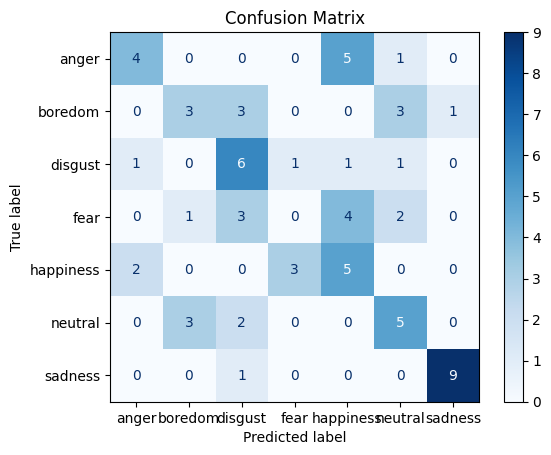

In [14]:
# ===========================
# PREDICTION & EVALUATION
# ===========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

vit_model.eval()  # set model to evaluation mode

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vit_model(inputs)
        preds = torch.argmax(outputs, dim=1)

        # store predictions and true labels
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ---------------------------
# Classification report
# ---------------------------
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[idx2label[i] for i in range(num_classes)]))

# ---------------------------
# Confusion matrix
# ---------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx2label[i] for i in range(num_classes)])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


<Figure size 1000x700 with 0 Axes>

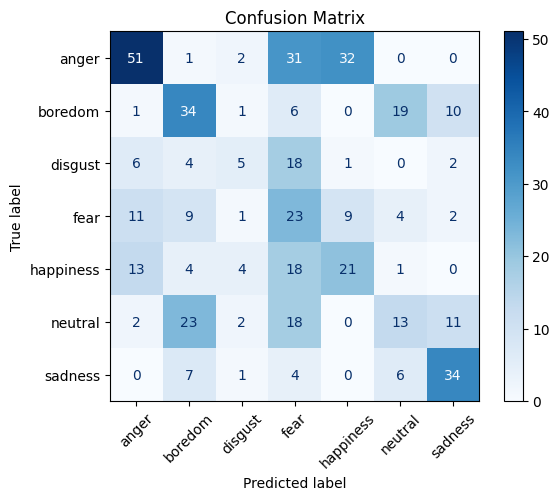

Classification Report:

              precision    recall  f1-score   support

       anger       0.61      0.44      0.51       117
     boredom       0.41      0.48      0.44        71
     disgust       0.31      0.14      0.19        36
        fear       0.19      0.39      0.26        59
   happiness       0.33      0.34      0.34        61
     neutral       0.30      0.19      0.23        69
     sadness       0.58      0.65      0.61        52

    accuracy                           0.39       465
   macro avg       0.39      0.38      0.37       465
weighted avg       0.42      0.39      0.39       465



In [55]:

# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

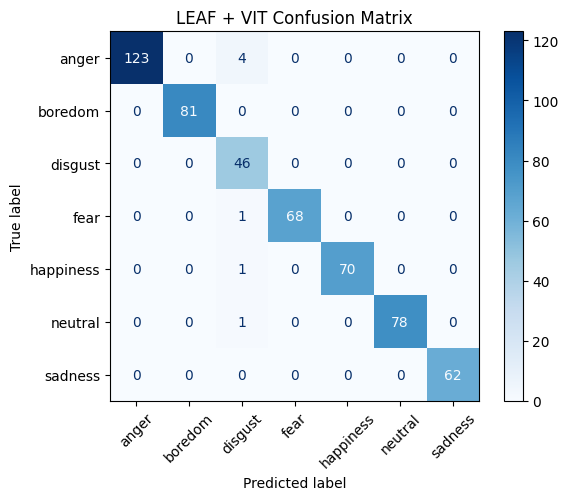

Classification Report:

              precision    recall  f1-score   support

       anger       1.00      0.97      0.98       127
     boredom       1.00      1.00      1.00        81
     disgust       0.87      1.00      0.93        46
        fear       1.00      0.99      0.99        69
   happiness       1.00      0.99      0.99        71
     neutral       1.00      0.99      0.99        79
     sadness       1.00      1.00      1.00        62

    accuracy                           0.99       535
   macro avg       0.98      0.99      0.98       535
weighted avg       0.99      0.99      0.99       535



In [ ]:
# LEAF + VIT
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("LEAF + VIT Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

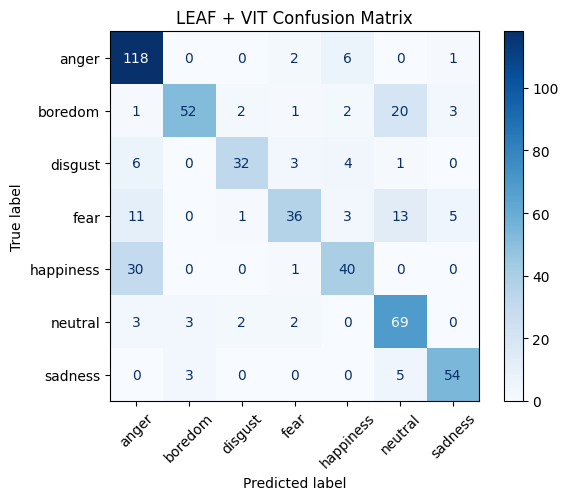

Classification Report:

              precision    recall  f1-score   support

       anger       0.70      0.93      0.80       127
     boredom       0.90      0.64      0.75        81
     disgust       0.86      0.70      0.77        46
        fear       0.80      0.52      0.63        69
   happiness       0.73      0.56      0.63        71
     neutral       0.64      0.87      0.74        79
     sadness       0.86      0.87      0.86        62

    accuracy                           0.75       535
   macro avg       0.78      0.73      0.74       535
weighted avg       0.77      0.75      0.74       535



In [28]:
# LEAF + LOCAL VIT
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("LEAF + VIT Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

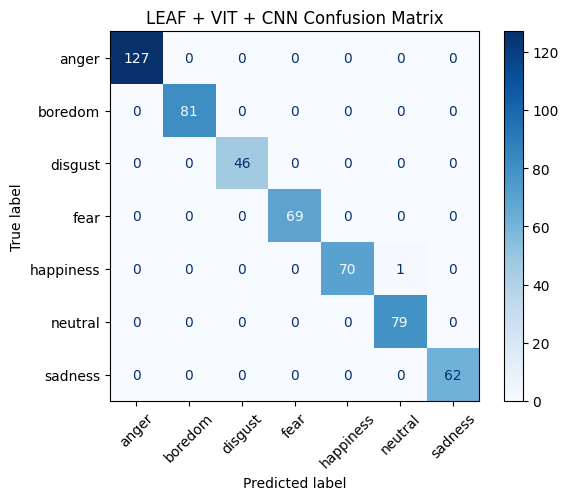

Classification Report:

              precision    recall  f1-score   support

       anger       1.00      1.00      1.00       127
     boredom       1.00      1.00      1.00        81
     disgust       1.00      1.00      1.00        46
        fear       1.00      1.00      1.00        69
   happiness       1.00      0.99      0.99        71
     neutral       0.99      1.00      0.99        79
     sadness       1.00      1.00      1.00        62

    accuracy                           1.00       535
   macro avg       1.00      1.00      1.00       535
weighted avg       1.00      1.00      1.00       535



In [38]:
# LEAF + VIT + CNN
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("LEAF + VIT + CNN Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

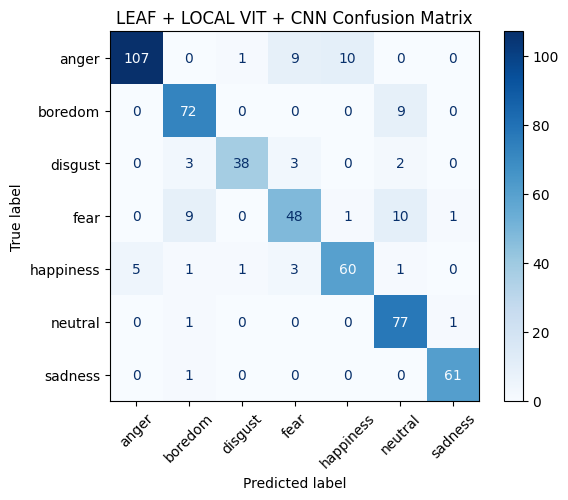

Classification Report:

              precision    recall  f1-score   support

       anger       0.96      0.84      0.90       127
     boredom       0.83      0.89      0.86        81
     disgust       0.95      0.83      0.88        46
        fear       0.76      0.70      0.73        69
   happiness       0.85      0.85      0.85        71
     neutral       0.78      0.97      0.87        79
     sadness       0.97      0.98      0.98        62

    accuracy                           0.87       535
   macro avg       0.87      0.87      0.86       535
weighted avg       0.87      0.87      0.87       535



In [47]:
# LEAF + LOCAL VIT + CNN
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("LEAF + LOCAL VIT + CNN Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

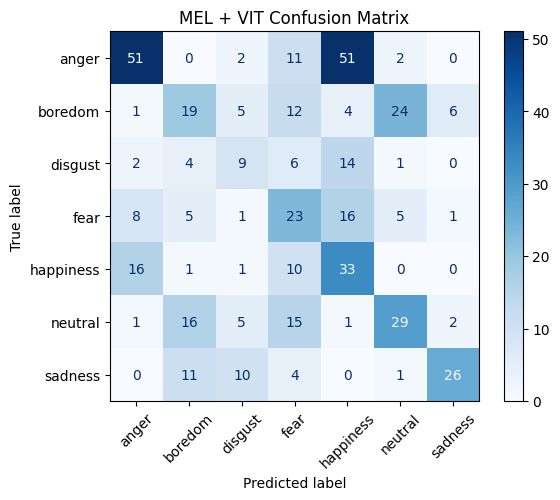

Classification Report:

              precision    recall  f1-score   support

       anger       0.65      0.44      0.52       117
     boredom       0.34      0.27      0.30        71
     disgust       0.27      0.25      0.26        36
        fear       0.28      0.39      0.33        59
   happiness       0.28      0.54      0.37        61
     neutral       0.47      0.42      0.44        69
     sadness       0.74      0.50      0.60        52

    accuracy                           0.41       465
   macro avg       0.43      0.40      0.40       465
weighted avg       0.46      0.41      0.42       465



In [23]:
# MEL + VIT
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("MEL + VIT Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

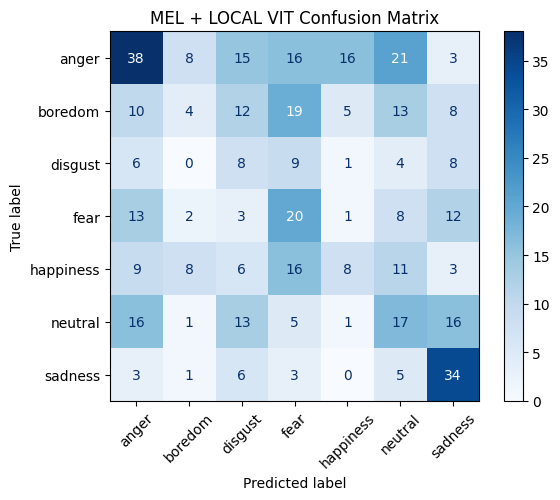

Classification Report:

              precision    recall  f1-score   support

       anger       0.40      0.32      0.36       117
     boredom       0.17      0.06      0.08        71
     disgust       0.13      0.22      0.16        36
        fear       0.23      0.34      0.27        59
   happiness       0.25      0.13      0.17        61
     neutral       0.22      0.25      0.23        69
     sadness       0.40      0.65      0.50        52

    accuracy                           0.28       465
   macro avg       0.26      0.28      0.25       465
weighted avg       0.27      0.28      0.26       465



In [28]:
# MEL + LOCAL VIT
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("MEL + LOCAL VIT Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

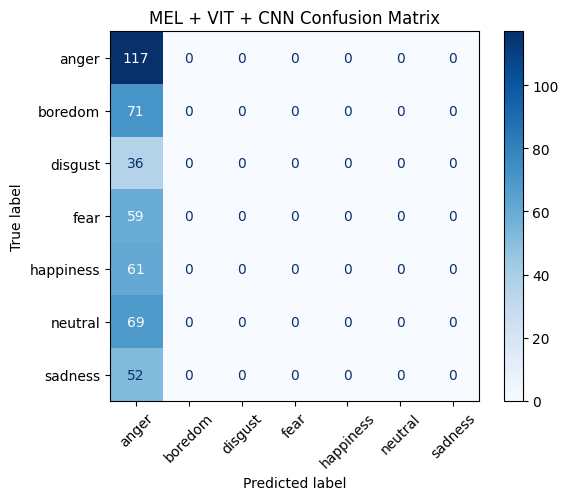

Classification Report:

              precision    recall  f1-score   support

       anger       0.25      1.00      0.40       117
     boredom       0.00      0.00      0.00        71
     disgust       0.00      0.00      0.00        36
        fear       0.00      0.00      0.00        59
   happiness       0.00      0.00      0.00        61
     neutral       0.00      0.00      0.00        69
     sadness       0.00      0.00      0.00        52

    accuracy                           0.25       465
   macro avg       0.04      0.14      0.06       465
weighted avg       0.06      0.25      0.10       465



c:\Users\Asus TUF Gaming A15\.conda\envs\leaf_vit\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Asus TUF Gaming A15\.conda\envs\leaf_vit\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Asus TUF Gaming A15\.conda\envs\leaf_vit\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_

In [36]:
# MEL + VIT + CNN
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("MEL + VIT + CNN Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

<Figure size 1000x700 with 0 Axes>

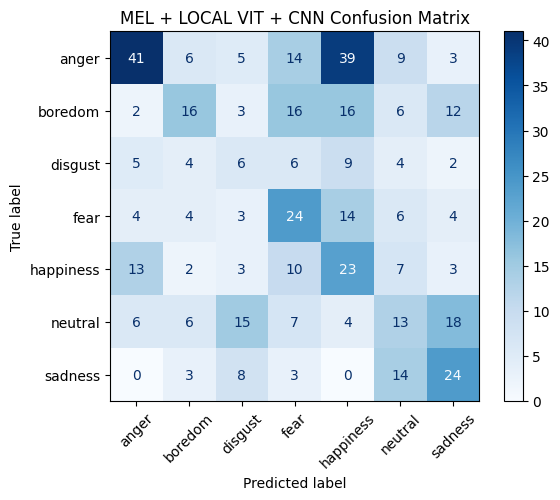

Classification Report:

              precision    recall  f1-score   support

       anger       0.58      0.35      0.44       117
     boredom       0.39      0.23      0.29        71
     disgust       0.14      0.17      0.15        36
        fear       0.30      0.41      0.35        59
   happiness       0.22      0.38      0.28        61
     neutral       0.22      0.19      0.20        69
     sadness       0.36      0.46      0.41        52

    accuracy                           0.32       465
   macro avg       0.32      0.31      0.30       465
weighted avg       0.36      0.32      0.32       465



In [48]:
# MEL + LOCAL VIT + CNN
# Map index to label names
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx2label.values()))

plt.figure(figsize=(10,7))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("MEL + LOCAL VIT + CNN Confusion Matrix")
plt.show()

# Precision, Recall, F1-score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx2label.values())))

In [ ]:
# MEL GREY
import os
import torch
import torch.nn.functional as F
import librosa
import numpy as np

# ===========================
# Paths
# ===========================
audio_dir = r"C:\Coding\emodb\wav"  # folder containing your audio files

# ===========================
# Collect all Mel features in memory
# ===========================
vit_features = []
labels = []

emo_map = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral"
}
idx2label = {i: emo for i, emo in enumerate(sorted(emo_map.values()))}
label2idx = {v: k for k, v in idx2label.items()}

for filename in os.listdir(audio_dir):
    if not filename.lower().endswith(".wav"):
        continue

    audio_path = os.path.join(audio_dir, filename)
    print(f"Processing {filename} ...")

    # ---------------------------
    # Load audio
    # ---------------------------
    y, sr = librosa.load(audio_path, sr=None)
    
    # ---------------------------
    # Compute Mel spectrogram
    # ---------------------------
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)  # [n_mels, time_frames]

    # ---------------------------
    # Convert to torch tensor, resize to 256x256, keep 1 channel
    # ---------------------------
    feat_tensor = torch.tensor(S_dB).unsqueeze(0).unsqueeze(0).float()  # [1, 1, n_mels, time_frames]
    feat_resized = F.interpolate(feat_tensor, size=(256, 256), mode="bilinear")  # [1, 1, 256, 256]
    feat_resized = feat_resized.squeeze(0)  # [1, 256, 256], still 1 channel

    vit_features.append(feat_resized)

    # ---------------------------
    # Label from filename (normal EMODB format: 03a01Fa.wav)
    # ---------------------------
    emo_code = filename[5]  # 'F' from '03a01Fa.wav'
    labels.append(label2idx[emo_map[emo_code]])

# ===========================
# Final dataset tensors
# ===========================
X = torch.stack(vit_features)  # [num_samples, 1, 256, 256]
y = torch.tensor(labels)       # [num_samples]

print("Final dataset shapes:")
print("  X:", X.shape)
print("  y:", y.shape)

# VIT WITH CNN BUT BIGGER
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# ---------------------------
# Helper
# ---------------------------
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# CNN for local features (flexible input channels)
# ---------------------------
class CNNLocalFeature(nn.Module):
    """
    CNN with numeric channel growth: in_channels -> 32 -> 64 -> 128
    Can accept Mel (1 channel) or LEAF (n_filters channels)
    """
    def __init__(self, in_channels=1, dropout=0.05):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Dropout2d(dropout)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.conv1(x)  # [B, 32, H, W]
        x = self.conv2(x)  # [B, 64, H, W]
        x = self.conv3(x)  # [B, 128, H, W]
        x = self.conv4(x)  # [B, 128, H, W]
        return x

# ---------------------------
# Transformer blocks
# ---------------------------
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.window_size = window_size
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)

        pad = self.window_size // 2
        k = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), k,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), v,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size, :]
            v_local = v[:, :, i:i+self.window_size, :]
            attn = torch.matmul(q[:, :, i:i+1, :], k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            attn = self.dropout(attn)
            out.append(torch.matmul(attn, v_local))
        out = torch.cat(out, dim=2)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([
            nn.ModuleList([
                LocalAttention(dim, heads=heads, dim_head=dim_head, window_size=3, dropout=dropout),
                FeedForward(dim, mlp_dim, dropout)
            ]) for _ in range(depth)
        ])

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

# ---------------------------
# ViT with CNN fusion (supports Mel or LEAF)
# ---------------------------
class ViTWithCNN(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads,
                 mlp_dim, in_channels=1, pool='cls', dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            "image dimensions must be divisible by the patch size."

        self.patch_height = patch_height
        self.patch_width = patch_width

        # CNN: in_channels -> 32 -> 64 -> 128
        self.cnn = CNNLocalFeature(in_channels=in_channels, dropout=0.05)
        self.linear_proj = nn.Linear(128 * patch_height * patch_width, dim)

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.num_patches = num_patches

        # ViT patch embedding from raw input
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.LayerNorm(in_channels * patch_height * patch_width),
            nn.Linear(in_channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape  # x: [B, in_channels, H, W]

        # CNN features
        cnn_feat = self.cnn(x)  # [B, 128, H, W]
        ph, pw = self.patch_height, self.patch_width
        cnn_patches = rearrange(cnn_feat, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=ph, p2=pw)
        cnn_tokens = self.linear_proj(cnn_patches)

        # ViT patch embedding
        vit_tokens = self.to_patch_embedding(x)

        # merge CNN + ViT tokens
        x = vit_tokens + cnn_tokens
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding[:, :(x.size(1))]
        x = self.dropout(x)

        x = self.transformer(x)
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]
        x = self.to_latent(x)
        return self.mlp_head(x)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict()

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

#Set up model
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch

# Create dataset
dataset = TensorDataset(X, y)

# Convert labels to numpy for easy indexing
labels = y.cpu().numpy() if torch.is_tensor(y) else y

train_indices = []
test_indices = []

# Loop over each class
num_train_per_class = 30
num_classes = len(torch.unique(y))

for cls in range(num_classes):
    cls_indices = (labels == cls).nonzero()[0]  # indices of this class
    
    # Shuffle indices
    cls_indices = torch.tensor(cls_indices)
    cls_indices = cls_indices[torch.randperm(len(cls_indices))]
    
    # Pick 20 for train, rest for test
    train_indices.extend(cls_indices[:num_train_per_class].tolist())
    test_indices.extend(cls_indices[num_train_per_class:].tolist())

# Create subsets
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

num_classes = 7
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
# ViTWithCNN / ViT
vit_model = ViTWithCNN(
    image_size=256,
    patch_size=32,
    num_classes=num_classes,
    dim=1024,
    depth=6,
    heads=16,
    mlp_dim=2048,
    dropout=0.1,
    emb_dropout=0.1,
).to(device)

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Training setup
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)
epochs = 30
early_stopping = EarlyStopping(patience=5, verbose=True)

# -------------------------
# Training loop
# -------------------------
for epoch in range(epochs):
    vit_model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vit_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_loss = total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    vit_model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vit_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(test_loader)
    val_acc = correct_val / total_val

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # -------------------------
    # Early stopping check
    # -------------------------
    early_stopping(val_loss, vit_model)
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

# -------------------------
# Load best model
# -------------------------
vit_model.load_state_dict(early_stopping.best_state)
print("Best model loaded.")

# ===========================
# PREDICTION & EVALUATION
# ===========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

vit_model.eval()  # set model to evaluation mode

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vit_model(inputs)
        preds = torch.argmax(outputs, dim=1)

        # store predictions and true labels
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ---------------------------
# Classification report
# ---------------------------
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[idx2label[i] for i in range(num_classes)]))

# ---------------------------
# Confusion matrix
# ---------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx2label[i] for i in range(num_classes)])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
